In [93]:
import numpy as np
import pandas as pd

In [94]:
df = pd.read_csv("https://raw.githubusercontent.com/Himanshu-1703/reddit-sentiment-analysis/refs/heads/main/data/reddit.csv")

df.head()

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1


In [95]:
df.shape

(37249, 2)

In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37249 entries, 0 to 37248
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   clean_comment  37149 non-null  object
 1   category       37249 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 582.1+ KB


In [97]:
df.isnull().sum()

,0
clean_comment,100
category,0


In [98]:
df[df["clean_comment"].isna()]

,clean_comment,category
413,NaN,0
605,NaN,0
2422,NaN,0
2877,NaN,0
3307,NaN,0
...,...,...
35975,NaN,0
36036,NaN,0
37043,NaN,0
37111,NaN,0


In [99]:
df.dropna(inplace=True)

In [100]:
df.duplicated().sum()

np.int64(350)

In [101]:
df[df.duplicated()]

,clean_comment,category
375,,0
392,,0
617,aurum mom,0
651,,0
1222,,0
...,...,...
36915,who won,0
37044,,0
37125,hari,0
37158,top kek,1


In [102]:
df.drop_duplicates(inplace=True)

In [103]:
df[(df['clean_comment'].str.strip() == '')]

,clean_comment,category
181,,0
4432,\n,0
10592,,0
16173,,0
32149,\n,0
34959,,0


In [104]:
df = df[~(df['clean_comment' ].str. strip() =='')]


In [105]:
# Convert the 'clean_comment' column to lowercase
df['clean_comment'] = df['clean_comment'].str.lower()
# Verify the transformation by displaying the first few rows
df.head()

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1


In [106]:
df[df['clean_comment']. apply(lambda x: x.endswith(' ') or x.startswith(' '))]

,clean_comment,category
0,family mormon have never tried explain them t...,1
1,buddhism has very much lot compatible with chr...,1
2,seriously don say thing first all they won get...,-1
3,what you have learned yours and only yours wha...,0
4,for your own benefit you may want read living ...,1
...,...,...
37241,let the janta decide not ulema clerics,0
37242,hona hai same with vaccination education insu...,0
37246,downvote karna tha par upvote hogaya,0
37247,haha nice,1


In [107]:
# Remove trailing and leading whitespaces from the 'clean_comment' column
df['clean_comment'] = df['clean_comment'].str.strip()

# Verify the transformation by checking for any remaining trailing whitespaces
df['clean_comment']. apply(lambda x: x. endswith(' ') or x.startswith(' ')). sum()


np.int64(0)

In [108]:
url_pattern = r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+'

comments_with_urls = df[df['clean_comment'].str.contains(url_pattern, regex=True)]

comments_with_urls.head()

,clean_comment,category


In [109]:
# Identify comments containing new line characters
comments_with_newline = df[df['clean_comment'].str.contains('\n')]
# Display the comments containing new line characters
comments_with_newline.head()

,clean_comment,category
448,what missing jpg\nand why this brilliant edit ...,1
781,india has been ruined congress and populist sc...,-1
847,like aap for its stand corruption and making p...,-1
871,reduced trade\ndeficit stronger rupee aren the...,0
1354,amsa press conference australian maritime safe...,1


In [110]:
# Remove new line characters from the 'clean_comment' column
df['clean_comment'] = df['clean_comment'].str.replace('\n', ' ', regex=True)
# Verify the transformation by checking for any remaining new lines
comments_with_newline_remaining = df[df['clean_comment'].str. contains(' \n')]
comments_with_newline_remaining

,clean_comment,category


EDA

<Axes: xlabel='category', ylabel='count'>

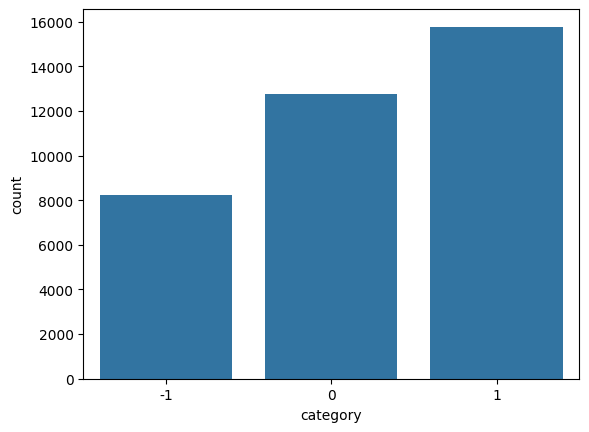

In [111]:
import seaborn as sns
import matplotlib.pyplot as plt
# distribution of classes
sns.countplot(data=df, x="category")

In [112]:
# frequency distribution of sentiments
df['category'].value_counts(normalize=True).mul(100).round(2)

,proportion
category,
1,42.86
0,34.71
-1,22.42


In [113]:
df['word_count'] = df['clean_comment'].apply(lambda x: len(x.split()))
df.sample(5)

,clean_comment,category,word_count
2825,where all the english majors represent history...,-1,10
7400,thanks can you make this weekly post,1,7
16591,not only him south has converted bjp just does...,1,34
17780,this stuart binny pitch,0,4
3116,remember recent interview where yogendra yadav...,1,43


In [114]:
df['word_count'].describe()

,word_count
count,36793.000000
mean,29.667464
std,56.790738
min,1.000000
25%,6.000000
50%,13.000000
75%,30.000000
max,1307.000000


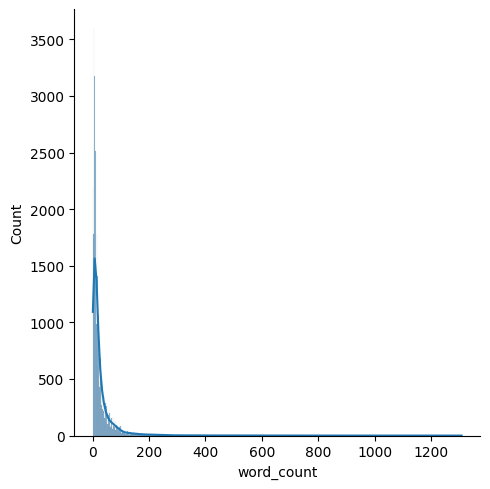

In [115]:
sns.displot(df['word_count'], kde=True)

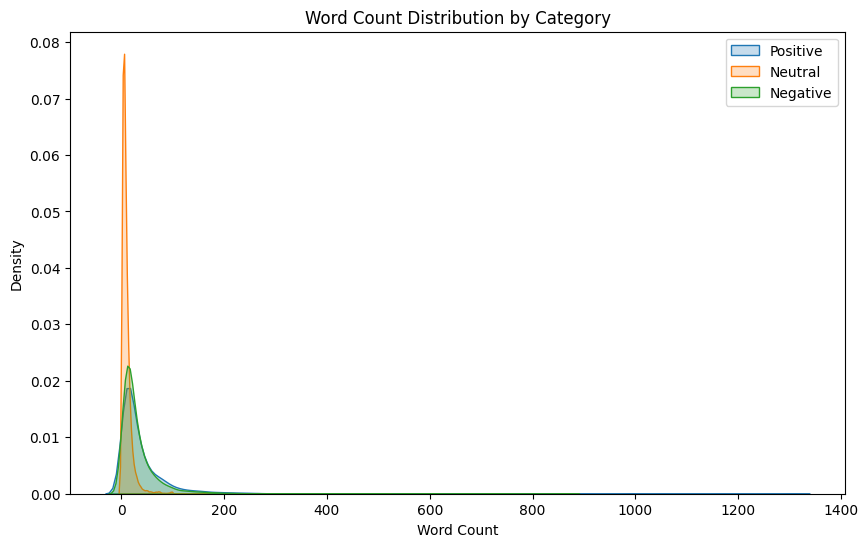

In [116]:
# Create the figure and axes
plt.figure(figsize=(10, 6))
# Plot KDE for category 1
sns.kdeplot(df[df['category'] == 1]['word_count'], label='Positive', fill=True)
# Plot KDE for category 0
sns.kdeplot(df[df['category'] == 0]['word_count'], label='Neutral', fill=True)
# Plot KDE for category -1
sns.kdeplot(df[df['category'] == -1]['word_count'], label='Negative', fill=True)
# Add title and labels
plt. title('Word Count Distribution by Category')
plt. xlabel('Word Count')
plt.ylabel('Density')
# Add a legend
plt. legend()

<Axes: ylabel='word_count'>

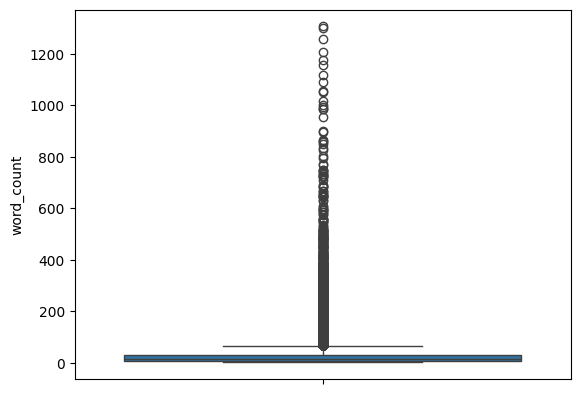

In [117]:
sns.boxplot(df['word_count'])

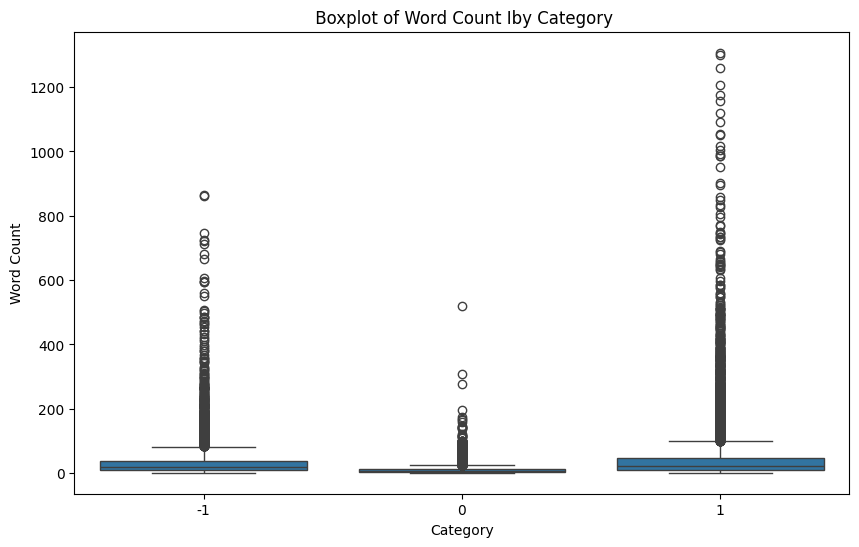

In [118]:
# Create a boxplot for the 'wordcount' column categorized by 'category'
plt.figure(figsize=(10, 6))
sns.boxplot (data=df, x='category', y='word_count')
plt.title(' Boxplot of Word Count Iby Category')
plt.xlabel('Category')
plt.ylabel('Word Count')
plt.show()

Positive comments (category 1): The median word count is relatively high, and there are several outliers with longer comments, indicating that positive comments tend to be more verbose.
Neutral comments (category 0): The median word count is the lowest, with a tighter interquartile range (IQR), suggesting that neutral comments are generally shorter.
Negative comments (category -1): The word count distribution is similar to positive comments but with a slightly lower median and fewer extreme outliers.

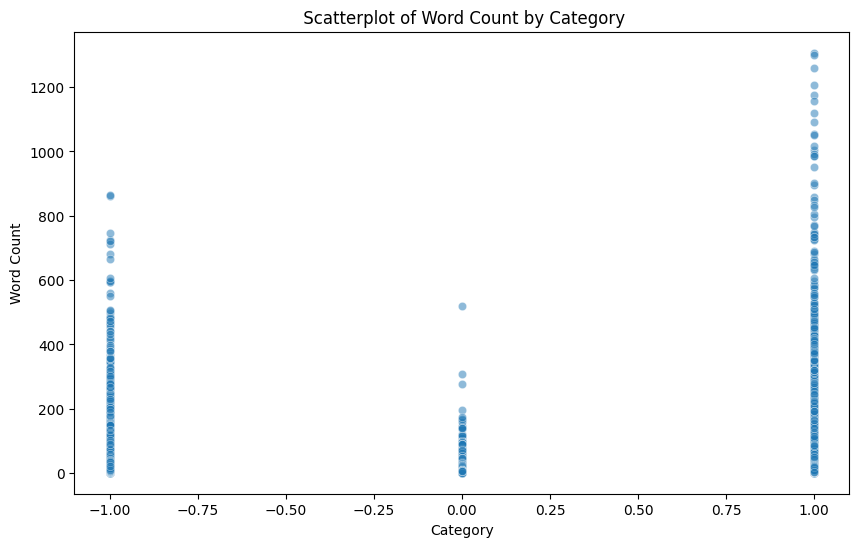

In [119]:
# Create a scatterplot between 'category' and 'wordcount'
plt.figure(figsize=(10, 6))
sns. scatterplot(data=df, x='category', y= 'word_count' , alpha=0.5)
plt.title(' Scatterplot of Word Count by Category')
plt. xlabel('Category')
plt.ylabel('Word Count' )
plt.show()

<Axes: xlabel='category', ylabel='word_count'>

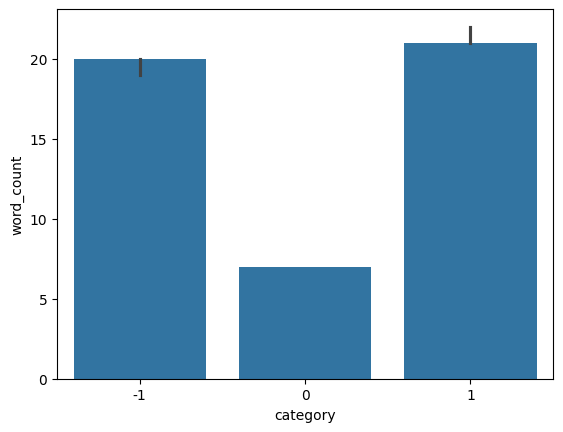

In [120]:
# median word counts among sentiments
sns.barplot(df, x='category',y='word_count', estimator='median')

In [121]:
!pip install nltk

In [122]:
from nltk.corpus import stopwords
#Download NLK stopwords if not already downloaded
import nltk
nltk.download('stopwords')
# Define the list of English stopwords
stop_words = set (stopwords.words('english'))
# Create a new column 'num_stop_words' by counting the number of stopwords in each comment
df['num_stop_words'] = df['clean_comment'].apply(lambda x: len([word for word in x.split() if word in stop_words]))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [123]:
df.sample(5)

,clean_comment,category,word_count,num_stop_words
21527,preach,0,1,0
11878,fed judge just decided anybody that lands the ...,0,15,7
32015,supreme leader showing his streanh,0,5,1
7893,india going get closer the west help contain c...,0,9,1
11602,wanna see the other,-1,4,2


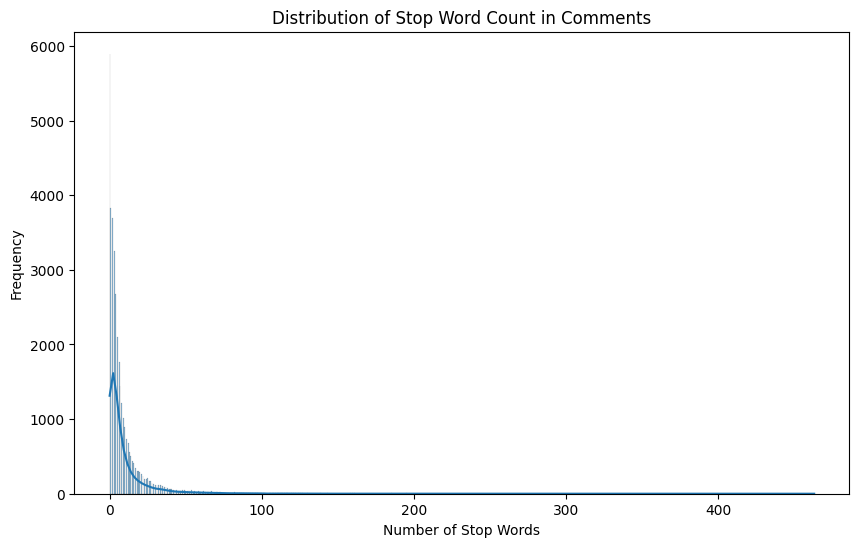

In [124]:
# Create a distribution plot (displot) for the 'num_stop_words' column
plt.figure(figsize=(10, 6))
sns.histplot(df['num_stop_words'], kde=True)
plt.title('Distribution of Stop Word Count in Comments')
plt.xlabel('Number of Stop Words')
plt.ylabel('Frequency')
plt.show()

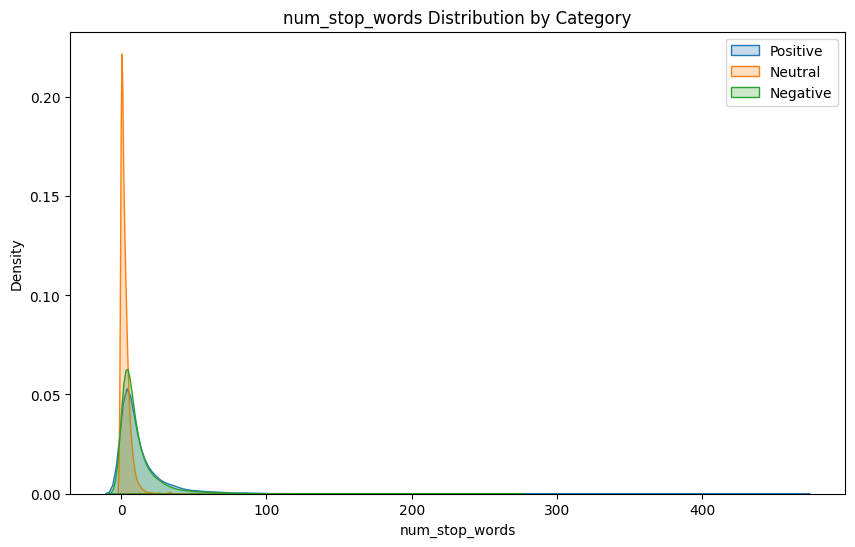

In [125]:
# Create the figure and axes
plt.figure(figsize=(10, 6))
# Plot KDE for category 1
sns.kdeplot(df[df['category'] == 1]['num_stop_words'], label='Positive', fill=True)
# Plot KDE for category 0
sns.kdeplot(df[df['category'] == 0]['num_stop_words'], label='Neutral', fill=True)
# Plot KDE for category -1
sns.kdeplot(df[df['category'] == -1]['num_stop_words'], label='Negative', fill=True)
# Add title and labels
plt. title('num_stop_words Distribution by Category')
plt. xlabel('num_stop_words')
plt.ylabel('Density')
# Add a legend
plt. legend()

<Axes: xlabel='category', ylabel='num_stop_words'>

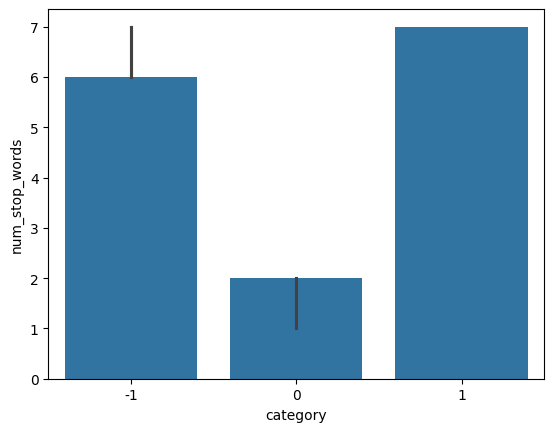

In [126]:
sns.barplot(df, x='category',y='num_stop_words', estimator='median')

/tmp/ipykernel_5589/3465179362.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_25_df, x='count', y='stop_word', palette='viridis')


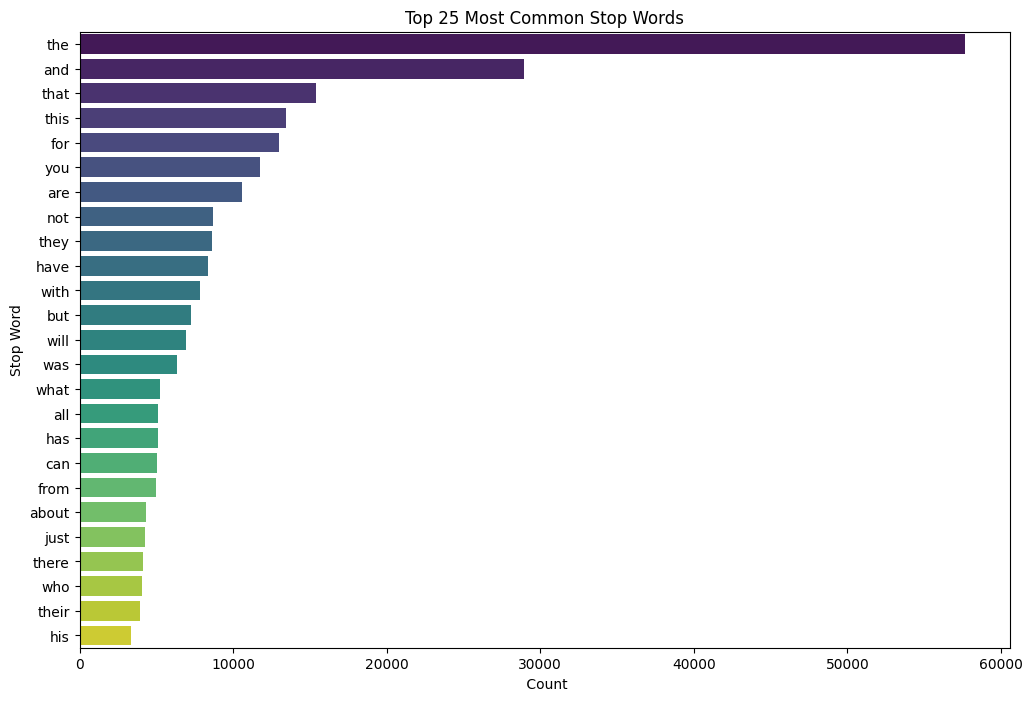

In [127]:
# Create a frequency distribution of stop words in the 'clean_comment' column
from collections import Counter
# Extract all stop words from the comments using the previously defined 'common_stopwords'
all_stop_words = [word for comment in df['clean_comment'] for word in comment. split() if word in stop_words]
# Count the most common stop words
most_common_stop_words = Counter (all_stop_words).most_common(25)
# Convert the most common stop words to a DataFrame for plotting
top_25_df = pd. DataFrame (most_common_stop_words, columns=['stop_word', 'count'])
# Create the barplot for the top 25 most common stop words
plt.figure(figsize=(12, 8))
sns.barplot(data=top_25_df, x='count', y='stop_word', palette='viridis')
plt.title('Top 25 Most Common Stop Words')
plt.xlabel(' Count' )
plt.ylabel('Stop Word')
plt. show()

In [128]:
df['num_chars'] = df['clean_comment']. apply(len)
df. head ()

,clean_comment,category,word_count,num_stop_words,num_chars
0,family mormon have never tried explain them th...,1,39,13,259
1,buddhism has very much lot compatible with chr...,1,196,59,1268
2,seriously don say thing first all they won get...,-1,86,40,459
3,what you have learned yours and only yours wha...,0,29,15,167
4,for your own benefit you may want read living ...,1,112,45,690


In [129]:
df['num_chars']. describe ()

,num_chars
count,36793.000000
mean,181.852798
std,359.702163
min,1.000000
25%,38.000000
50%,80.000000
75%,184.000000
max,8664.000000


In [130]:
from collections import Counter
# Combine all comments into one large string
all_text = ' '.join(df['clean_comment'])
# Count the frequency of each character
char_frequency = Counter(all_text)
# Convert the character frequency into a DataFrame for better display
char_frequency_df = pd.DataFrame(char_frequency.items(), columns=['character', 'frequency']).sort_values(by='frequency',ascending=True)

In [131]:
char_frequency_df['character'].values

array(['∀', '￼', 'ಳ', ..., 't', 'e', ' '], dtype=object)

In [132]:
char_frequency_df.tail(50)

,character,frequency
66,ि,232
456,ė,280
72,्,285
71,ो,305
67,ं,325
98,@,366
69,ी,394
60,\,463
68,े,519
57,”,665


In [133]:
# Create a new column "num punctuation_chars' to count punctuation characters in each comment
df['num punctuation_chars'] = df['clean_comment'].apply(
lambda x: sum([1 for char in x if char in '•,!?;:"\'()[I-'])
)
df. sample(5)

,clean_comment,category,word_count,num_stop_words,num_chars,num punctuation_chars
10446,poor people justice boner still half can still...,-1,141,54,822,0
22027,damn jds government karnataka,0,4,0,29,0
33745,mexican sleepoff,0,2,0,16,0
12948,not muslim nor have anything against vande mat...,-1,34,15,189,0
10777,there are lot valid criticisms demonetization ...,-1,51,22,328,0


In [134]:
df['num punctuation_chars'].describe()

,num punctuation_chars
count,36793.000000
mean,0.001006
std,0.074273
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,11.000000


/tmp/ipykernel_5589/3067808750.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_25_bigrams_df, x='count', y='bigram', palette='magma')


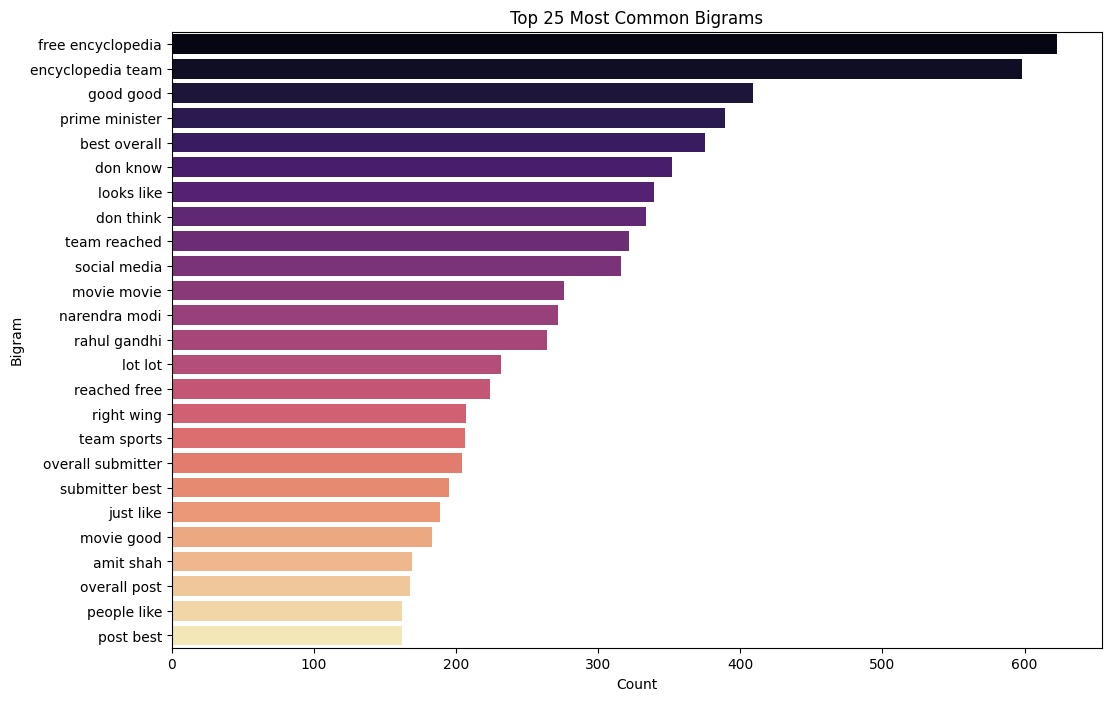

In [135]:
from sklearn. feature_extraction. text import CountVectorizer
# Create a function to extract the top 25 bigrams
def get_top_ngrams (corpus, n=None) :
    vec = CountVectorizer(ngram_range=(2, 2), stop_words='english'). fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx])for word, idx in vec.vocabulary_.items()]
    words_freq = sorted (words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:n]
# Get the top 25 bigrams
top_25_bigrams = get_top_ngrams (df['clean_comment'], 25)
# Convert the bigrams into a DataFrame for plotting
top_25_bigrams_df = pd.DataFrame (top_25_bigrams, columns=['bigram', 'count'])
# Plot the countplot for the top 25 bigrams
plt.figure(figsize=(12, 8))
sns.barplot(data=top_25_bigrams_df, x='count', y='bigram', palette='magma')
plt.title('Top 25 Most Common Bigrams')
plt.xlabel('Count')
plt.ylabel('Bigram')
plt.show()


In [136]:
# Remove non-English characters from the 'clean_comment' column
# Keeping only standard English letters, digits, and common punctuation
import re
df['clean_comment'] = df['clean_comment'].apply(lambda x: re.sub(r'[^A-Za-z0-9\s!?.,]','', str(x)))

In [137]:
all_text = ' '.join(df['clean_comment'])
# Count the frequency of each character
char_frequency = Counter(all_text)
# Convert the character frequency into a DataFrame for better display
char_frequency_df = pd.DataFrame(char_frequency.items(), columns=['character', 'frequency']).sort_values(by='frequency',ascending=True)
char_frequency_df

,character,frequency
39,,1
40,,3
37,\t,11
38,,76
33,8,1199
36,7,1291
28,6,1403
29,4,1573
35,3,1617
27,5,1631


In [138]:
df.head()

,clean_comment,category,word_count,num_stop_words,num_chars,num punctuation_chars
0,family mormon have never tried explain them th...,1,39,13,259,0
1,buddhism has very much lot compatible with chr...,1,196,59,1268,0
2,seriously don say thing first all they won get...,-1,86,40,459,0
3,what you have learned yours and only yours wha...,0,29,15,167,0
4,for your own benefit you may want read living ...,1,112,45,690,0


In [139]:
from nltk. corpus import stopwords
# Defining stop words but keeping essential ones for sentiment analysis
stop_words = set(stopwords.words('english')) - {'not', 'but' ,'however' ,'no','yet'}
# Remove stop words from 'clean_comment' column, retaining essential ones
df['clean_comment'] = df['clean_comment']. apply(
 lambda x: ' '.join([word for word in x.split() if word.lower() not in stop_words])
)

In [140]:
df.head()

,clean_comment,category,word_count,num_stop_words,num_chars,num punctuation_chars
0,family mormon never tried explain still stare ...,1,39,13,259,0
1,buddhism much lot compatible christianity espe...,1,196,59,1268,0
2,seriously say thing first get complex explain ...,-1,86,40,459,0
3,learned want teach different focus goal not wr...,0,29,15,167,0
4,benefit may want read living buddha living chr...,1,112,45,690,0


In [141]:
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')
# Define the lemmatizer
lemmatizer = WordNetLemmatizer()
# Apply lemmatization to the 'clean_comment_no_stopwords' column
df[' clean_comment'] = df['clean_comment'].apply(
   lambda x: ' '.join([lemmatizer. lemmatize(word) for word in x.split()])
)
df. head ()

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


,clean_comment,category,word_count,num_stop_words,num_chars,num punctuation_chars,clean_comment
0,family mormon never tried explain still stare ...,1,39,13,259,0,family mormon never tried explain still stare ...
1,buddhism much lot compatible christianity espe...,1,196,59,1268,0,buddhism much lot compatible christianity espe...
2,seriously say thing first get complex explain ...,-1,86,40,459,0,seriously say thing first get complex explain ...
3,learned want teach different focus goal not wr...,0,29,15,167,0,learned want teach different focus goal not wr...
4,benefit may want read living buddha living chr...,1,112,45,690,0,benefit may want read living buddha living chr...


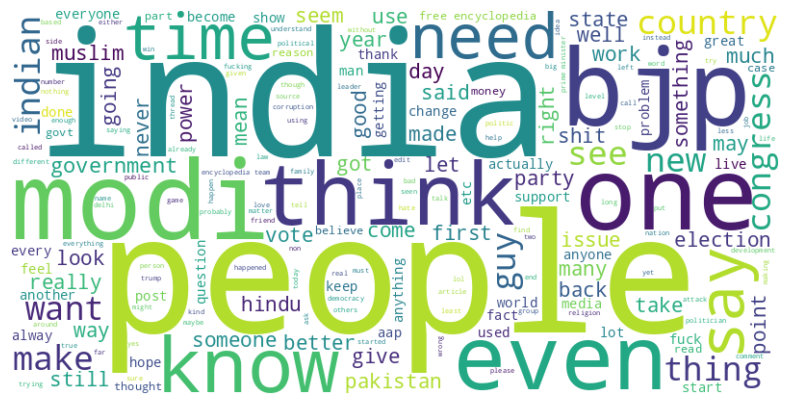

In [142]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def plot_word_cloud (text) :
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(text))
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.show()

plot_word_cloud(df['clean_comment'])

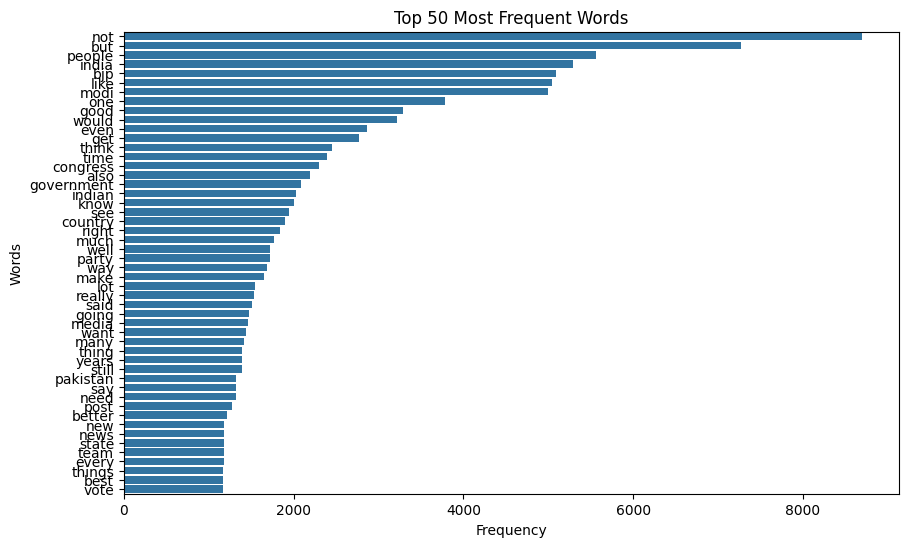

In [143]:
def plot_top_n_words (df, n=20) :
    """ Plot the top N most frequent words in the dataset."""
    # Flatten all words in the content column
    words = ' '.join(df['clean_comment']).split()
    # Get the top N most common words
    counter = Counter (words)
    most_common_words = counter.most_common (n)
    # Split the words and their counts for plotting
    words, counts = zip (*most_common_words)
    # Plot the top N words
    plt.figure(figsize=(10, 6))
    sns.barplot(x=list(counts), y=list(words))
    plt.title(f'Top {n} Most Frequent Words')
    plt.xlabel('Frequency')
    plt. ylabel('Words')
    plt. show()

# Example usage
plot_top_n_words (df, n=50)